In [18]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

1. Відкрити та зчитати наданий файл з даними.

In [19]:
df = pd.read_csv("ПР5-пгр1.csv")
df

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,Class
0,0.266074,-0.165620,0.320980,0.483299,0.172340,0.273364,0.371178,0.929823,0.251173,0.159345,A
1,0.130292,0.870736,-3.210528,0.062493,0.261718,1.436060,1.465940,0.636203,0.282354,0.515587,A
2,-0.116585,0.069915,0.068476,-0.783147,0.261718,0.439463,-0.081827,-0.888236,-0.123005,0.582939,A
3,0.031541,0.297600,-3.210528,-0.583590,-0.721442,-0.307984,0.710932,1.051693,0.594169,-0.533994,A
4,0.229043,0.807926,-0.052442,0.082634,0.261718,0.148790,0.635431,0.051062,0.032902,-0.086652,F
...,...,...,...,...,...,...,...,...,...,...,...
8245,-0.338774,-0.094960,0.527252,1.857252,-1.257711,1.768258,-1.289840,0.919882,-0.247731,2.817610,X
8246,1.216550,0.156278,-0.013322,0.353593,0.172340,0.730137,0.484429,-0.418713,-0.777816,0.510500,A
8247,0.056229,0.054213,0.392108,-0.028960,0.261718,-1.346105,0.069175,0.788653,0.500624,-1.142223,H
8248,0.019197,-0.040001,0.288973,-0.042597,0.261718,0.148790,0.333428,-0.303949,-0.808997,0.057600,F


2. Визначити та вивести кількість записів.

In [20]:
df.shape[0]

8250

3. Видалити атрибут Class.

In [21]:
X = df.drop('Class', axis=1)
df['Class'].value_counts()

Class
A    3422
F    1547
E     874
I     661
H     410
X     405
G     357
D     279
Y     208
C      87
Name: count, dtype: int64

4. Вивести атрибути, що залишилися.

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn import set_config
from scipy import stats

set_config(transform_output='pandas')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

z_scores = np.abs(stats.zscore(X_scaled))

outlier_mask = (z_scores > 12).any(axis=1)

X_scaled= X_scaled[~outlier_mask]

X_scaled

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10
0,0.260195,-0.046662,0.288832,0.481599,0.161336,0.223855,0.265914,0.920010,0.216449,0.159108
1,0.124106,0.191541,-2.805874,0.068021,0.253531,1.229960,1.053761,0.626771,0.244429,0.509681
2,-0.123330,0.007475,0.067560,-0.763093,0.253531,0.367584,-0.060092,-0.895689,-0.119313,0.575961
3,0.025131,0.059807,-2.805874,-0.566964,-0.760619,-0.279197,0.510418,1.041722,0.524230,-0.523197
4,0.223080,0.177104,-0.038402,0.087816,0.253531,0.116059,0.456084,0.042390,0.020587,-0.082974
...,...,...,...,...,...,...,...,...,...,...
8245,-0.346022,-0.030421,0.469591,1.831952,-1.313793,1.517417,-0.929441,0.910082,-0.231234,2.775069
8246,1.212823,0.027325,-0.004121,0.354121,0.161336,0.619110,0.347415,-0.426776,-0.706897,0.504675
8247,0.049875,0.003866,0.351163,-0.021861,0.253531,-1.177504,0.048577,0.779023,0.440289,-1.121746
8248,0.012759,-0.017789,0.260784,-0.035264,0.253531,0.116059,0.238747,-0.312161,-0.734876,0.058983


5. Використовуючи функцію KMeans бібліотеки scikit-learn, виконати
розбиття набору даних на кластери з випадковою початковою
ініціалізацією і вивести координати центрів кластерів.
Оптимальну кількість кластерів визначити на основі початкового
набору даних трьома різними способами:
1) elbow method;
2) average silhouette method;
3) prediction strength method (див. п. 9.2.3 Determining the Number of
Clusters книжки Andriy Burkov. The Hundred-Page Machine Learning
Book). <br>
Отримані результати порівняти і пояснити, який метод дав кращий
результат і чому так (на Вашу думку).

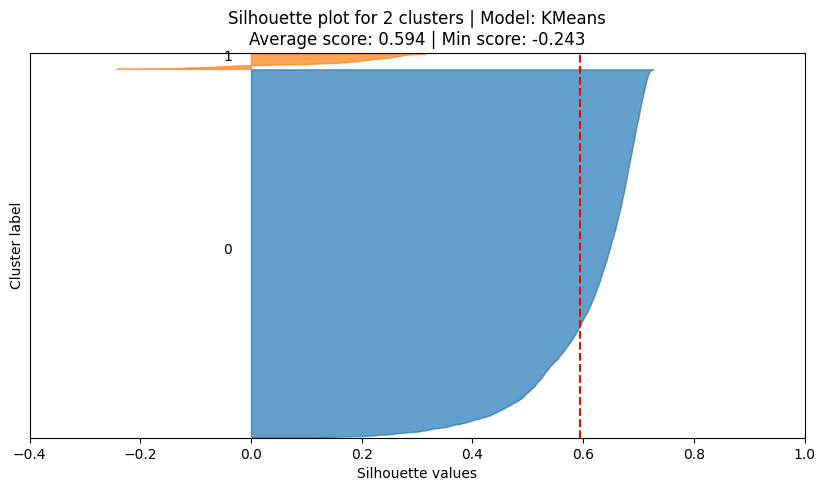

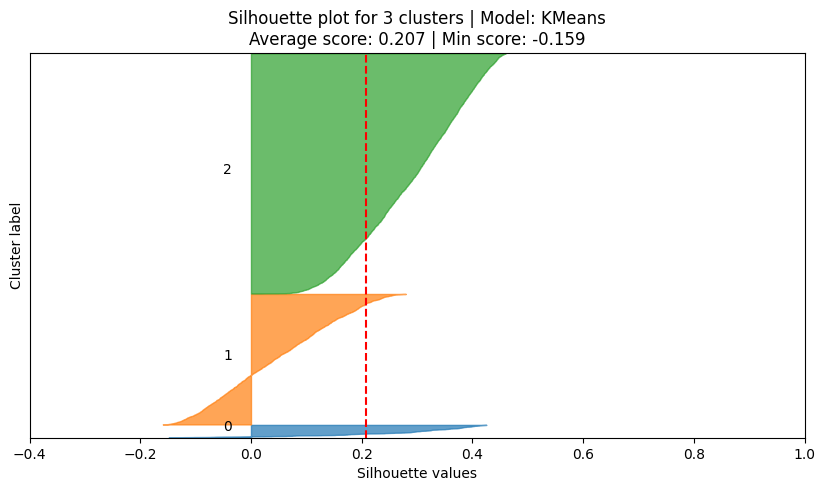

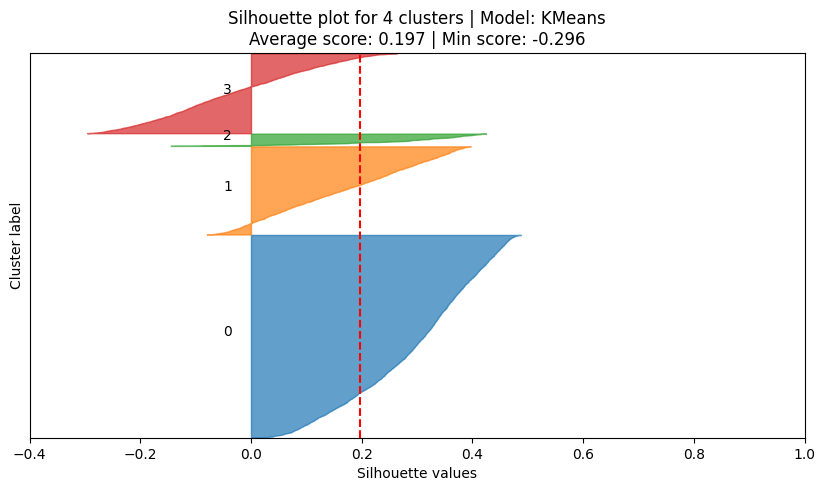

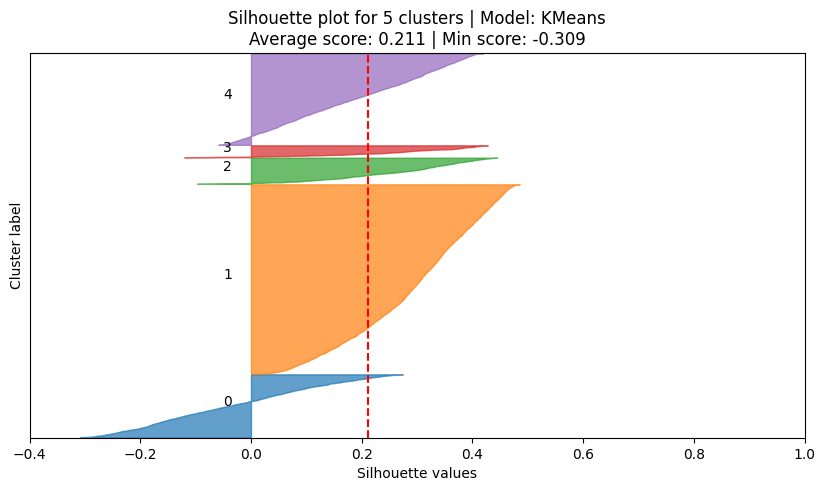

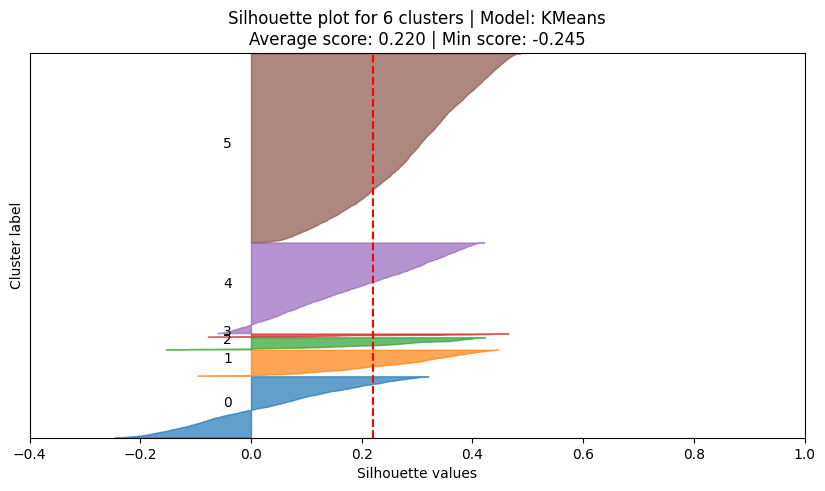

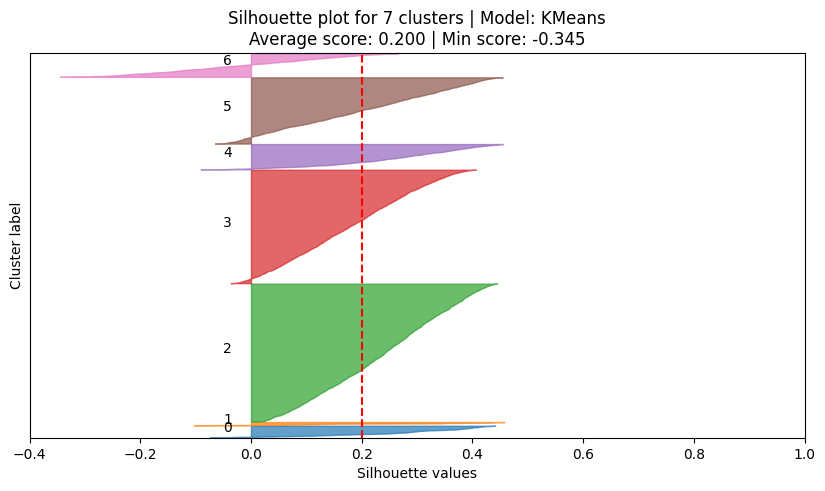

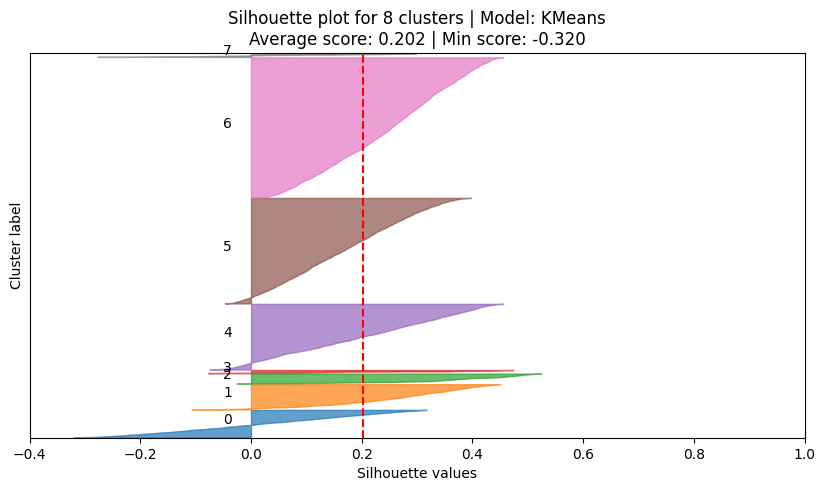

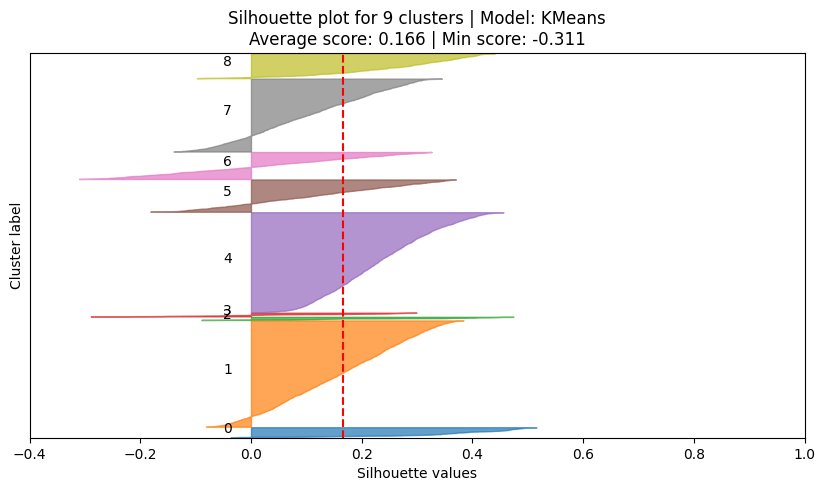

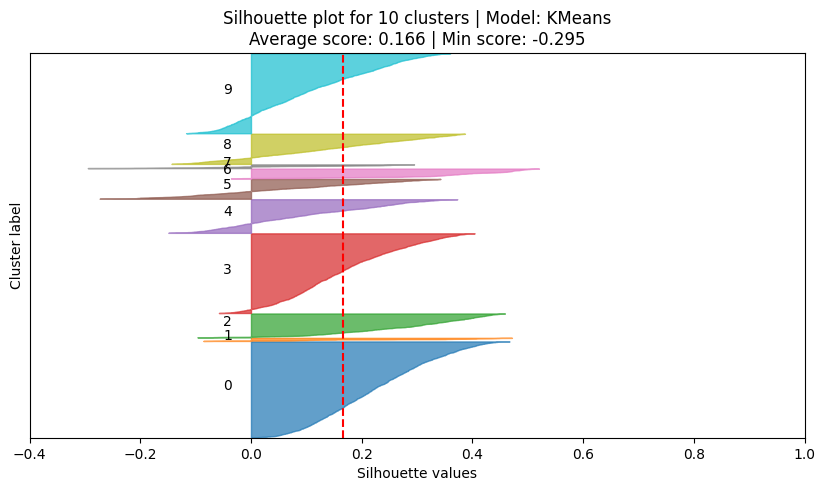

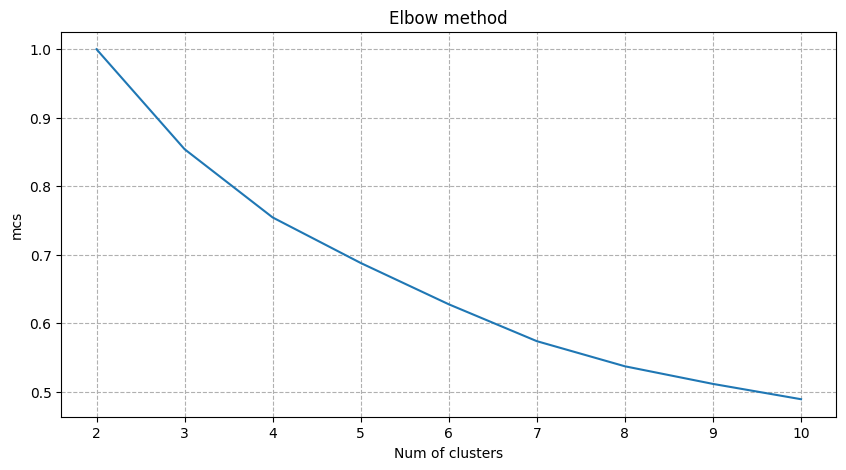

In [23]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_samples
from sklearn.model_selection import train_test_split

wcss = [] #within-cluster sum of squares

def plot_silhouette(X, model):
	labels = model.labels_

	unique_labels = np.unique(labels)
	n_clusters = len(unique_labels)

	if n_clusters < 2:
		print("Only one claster in model")
		return

	sil_values = silhouette_samples(X, labels)
	sil_score = sil_values.mean()
	
	fig, ax1 = plt.subplots()
	fig.set_size_inches(10, 5)

	ax1.set_xlim([-0.4, 1])
	ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

	y_lower = 10
	
	for i in range(n_clusters):
		cluster_id = unique_labels[i]
		
		ith_cluster_sil_values = sil_values[labels == cluster_id]
		ith_cluster_sil_values.sort()

		size_cluster_i = ith_cluster_sil_values.shape[0]
		y_upper = y_lower + size_cluster_i

		cmap = plt.get_cmap('tab10')
		color = cmap(cluster_id)
		ax1.fill_betweenx(
			np.arange(y_lower, y_upper),
			0,
			ith_cluster_sil_values,
			facecolor=color,
			edgecolor=color,
			alpha=0.7,
		)

		ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(cluster_id))

		y_lower = y_upper + 10

	ax1.set_title(f"Silhouette plot for {n_clusters} clusters | Model: {type(model).__name__}\nAverage score: {sil_score:.3f} | Min score: {sil_values.min():.3f}")
	ax1.set_xlabel("Silhouette values")
	ax1.set_ylabel("Cluster label")

	ax1.axvline(x=sil_score, color="red", linestyle="--")

	ax1.set_yticks([]) 
	ax1.set_xticks(np.arange(-0.4, 1.1, 0.2))

	plt.show()

for n_clusters in range(2, 11):
	clusterer = KMeans(n_clusters=n_clusters, init='random', random_state=129, n_init=100)
	clusterer.fit_predict(X_scaled)

	wcss.append(clusterer.inertia_)
	plot_silhouette(X_scaled, clusterer)

	
wcss = [s/(max(wcss)) for s in wcss]  

plt.figure(figsize=(10,5))
plt.plot(range(2, 11), wcss)
plt.title("Elbow method")
plt.xticks(range(2, 11))
plt.xlabel('Num of clusters')
plt.ylabel('mcs')
plt.grid(linestyle='--')
plt.show()


In [24]:
from sklearn.model_selection import train_test_split

# prediction strength
def calc_ps(n_clusters, predicted_train_model, test_model):
	min_ps = 1

	for cluster_id in range(n_clusters):
		indexes = np.where(test_model.labels_ == cluster_id)[0]

		n = indexes.size

		if n < 2:
			continue

		denom = n * (n - 1)
		
		sum_matrix = 0
		
		for i in range(n):
			for j in range(n):
				if i == j: continue
				if predicted_train_model[indexes[i]] == predicted_train_model[indexes[j]]:
					sum_matrix += 1	

		ps = sum_matrix / denom
		
		if ps < min_ps:
			min_ps = ps
		
	return min_ps

X_train, X_test = train_test_split(X_scaled, test_size=0.5, random_state=129)

for k in range(2, 11):
	train_model = KMeans(n_clusters=k, init='random', random_state=129, n_init=50).fit(X_train)
	test_model = KMeans(n_clusters=k, init='random', random_state=129, n_init=50).fit(X_test)

	pred = train_model.predict(X_test)

	min_ps = 1
	
   
	print(f"k: {k}, ps: {calc_ps(k, pred, test_model)}")
  
  

k: 2, ps: 0.7418399375492979
k: 3, ps: 0.7911505205643257
k: 4, ps: 0.8980865562252037
k: 5, ps: 0.8371861250562539
k: 6, ps: 0.5171669981933318
k: 7, ps: 0.8349641434262948
k: 8, ps: 0.7718493909191584
k: 9, ps: 0.5978231030835002
k: 10, ps: 0.4023840100102078


6. За раніш обраної кількості кластерів багаторазово проведіть
кластеризацію методом k-середніх, використовуючи для початкової
ініціалізації метод k-means++.
Виберіть найкращий варіант кластеризації. Який кількісний критерій
Ви обрали для відбору найкращої кластеризації?

In [25]:
X_train, X_test = train_test_split(X_scaled, test_size=0.5, random_state=129)
best_score = -1
best_i = -1

for i in range(5):
	train_model = KMeans(n_clusters=4, random_state=i).fit(X_train)
	test_model = KMeans(n_clusters=4, random_state=i).fit(X_test)

	pred = train_model.predict(X_test)

	score = calc_ps(4, pred, test_model)

	if score > best_score:
		best_score = score
		best_i = i
 
kmeans_model = KMeans(n_clusters=4, random_state=i).fit(X_scaled)
print(best_score, best_i)

0.9043767407097177 2


7. Використовуючи функцію AgglomerativeClustering бібліотеки scikit-
learn, виконати розбиття набору даних на кластери. Кількість кластерів

обрати такою ж самою, як і в попередньому методі. Вивести
координати центрів кластерів.

In [26]:
from sklearn.cluster import AgglomerativeClustering

agg_model = AgglomerativeClustering(n_clusters=4)

agg_labels = agg_model.fit_predict(X_scaled)

agg_centers = []

for cluster_id in range(4):

	cluster_points = X_scaled[agg_labels == cluster_id]
	
	center = cluster_points.mean(axis=0)
	agg_centers.append(center)
	
	print(f"сluster {cluster_id + 1}: {round(center, 34).to_list()}")



сluster 1: [-0.010292452011614652, -0.03461802455721489, -0.7670273116576322, -0.10971551704057667, 0.1399055699395, 0.8872665303471656, 0.19230299291146802, -0.4849706774104641, -0.2656249517219149, 0.8918982155540393]
сluster 2: [0.04784380826725193, -0.018121523069218385, 0.2444365778483092, 0.46859109326520865, 0.2028442914142443, -0.020453154480543818, 0.01849550259464322, 0.5893967426658117, 0.464271842376472, 0.11653014842968283]
сluster 3: [0.18902000885408118, -0.01100360433825483, 0.14332218574425473, -0.6006767888051937, 0.0031111613948361714, -0.5117641986388939, -0.1636169152365181, -0.5737787797836975, -0.44632942746342297, -0.6917211472047856]
сluster 4: [-3.2988806213359343, 0.3230764341608659, -0.5844293449381958, -0.1322613691026634, -5.002529451554403, -0.24195317862039573, -0.04436845096840378, 0.23086617000684428, -1.019039826582065, -0.29211248824704145]


8. Порівняти результати двох використаних методів кластеризації.

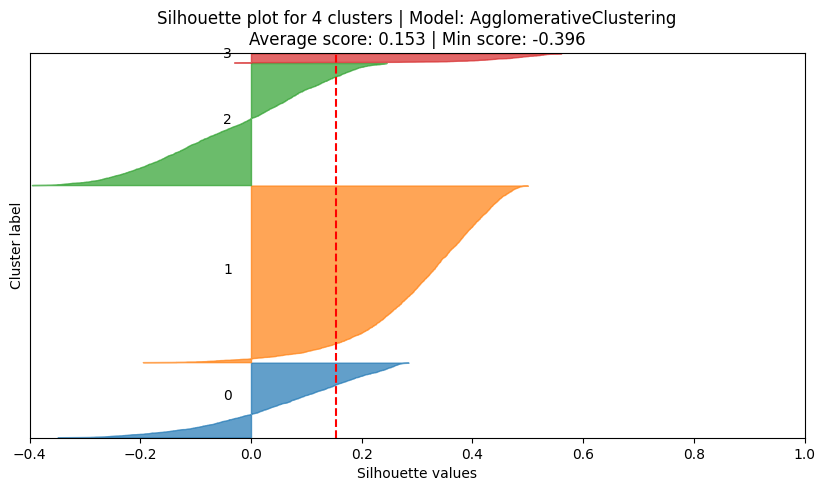

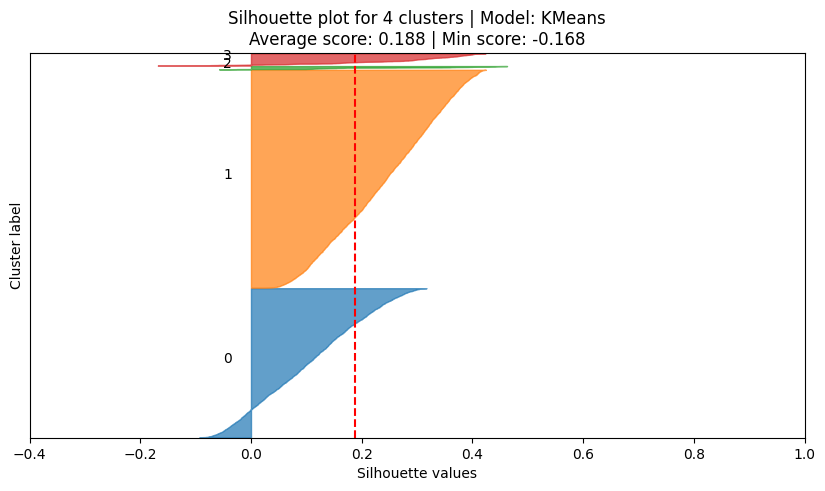

In [28]:

plot_silhouette(X_scaled, agg_model.fit(X_scaled))
plot_silhouette(X_scaled, kmeans_model.fit(X_scaled))
